In [5]:
import numpy as np
import time
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import scipy.stats as stats
import glob
import os
import subprocess as sp
import pandas as pd

In [46]:
window_sizes = [10, 20, 30, 40, 50, 100]
t_lsmash = []
t_smash = []
r_lsmash = []
r_smash = []
t_dtw = []
r_dtw = []
for ws in window_sizes:
    df = pd.read_csv('performance_compare_ws{}_sl500.csv'.format(ws), index_col=0)
    t_lsmash += list(df.t_lsmash)
    t_smash += list(df.t_smash)
    r_lsmash += list(df.r_lsmash)
    r_smash += list(df.r_smash)
    t_dtw.append(df.t_dtw.mean())
    r_dtw.append(df.r_dtw.mean())
    
print('lsmash ratio = {}, run time = {}'.format(12.5 *(np.mean(r_lsmash) - .3), np.mean(t_lsmash)))
print('smash ratio = {}, run time = {}'.format(12.5 * (np.mean(r_smash) - .3), np.mean(t_smash)))
for i in range(len(window_sizes)):
    print('window size = {}, ratio = {}, run time = {}'.format(window_sizes[i], 12.5 * (r_dtw[i] - .3), t_dtw[i]))

lsmash ratio = 1.9970899416673218, run time = 0.04220361232757568
smash ratio = 2.7965172621149845, run time = 1.037465644876162
window size = 10, ratio = 3.979516158712231, run time = 0.58685462474823
window size = 20, ratio = 2.174741623836033, run time = 1.0153813064098358
window size = 30, ratio = 1.877721407605823, run time = 1.4238555967807769
window size = 40, ratio = 1.6254639899324526, run time = 1.80772873878479
window size = 50, ratio = 1.518386773841998, run time = 2.17072606921196
window size = 100, ratio = 1.252119964522897, run time = 4.031478033065796


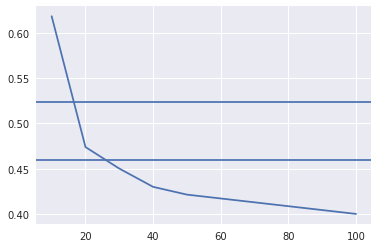

In [42]:
plt.figure()
# plt.plot(window_sizes, t_dtw, label='dtw run time')
plt.plot(windowb_sizes, r_dtw, label='dtw separation')
plt.axhline(np.mean(r_lsmash), label='lsmash separation')
plt.axhline(np.mean(r_smash), label='smash separation')
plt.show()

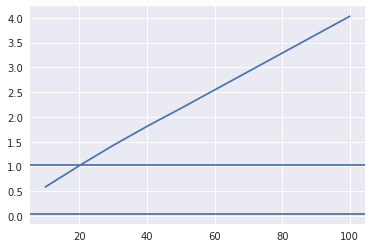

In [43]:
plt.figure()
# plt.plot(window_sizes, t_dtw, label='dtw run time')
plt.plot(window_sizes, t_dtw, label='dtw run time')
plt.axhline(np.mean(t_lsmash), label='lsmash run time')
plt.axhline(np.mean(t_smash), label='smash run time')
plt.show()

In [32]:
t_dtw = df.t_dtw.mean()
t_smash = df.t_smash.mean()
t_lsmash = df.t_lsmash.mean()

## Histograms

In [45]:
plt.figure()
ax = sns.distplot(df.r_lsmash, bins=15, label='lsmash ({:.3f}s)'.format(t_lsmash))
sns.distplot(df.r_dtw, bins=15, label='dtw20 ({:.3f}s)'.format(t_dtw))
sns.distplot(df.r_smash, bins=15, label='smash ({:.3f}s)'.format(t_smash))

ax.axvline(np.mean(df.r_lsmash), color='blue')
ax.axvline(np.mean(df.r_dtw), color='green')
ax.axvline(np.mean(df.r_smash), color='red')

plt.legend(fontsize=15)
plt.title('SAE ratio', fontsize=20)
plt.show()

TypeError: unsupported format string passed to list.__format__

In [35]:
matrix = np.array([df.r_lsmash.values, df.r_smash.values, df.r_dtw.values])
np.corrcoef(matrix)

array([[1.        , 0.17019733, 0.82452927],
       [0.17019733, 1.        , 0.23688717],
       [0.82452927, 0.23688717, 1.        ]])

In [36]:
matrix.shape

(3, 200)

In [49]:
df = pd.read_csv('performance_compare_sl500.csv', index_col=0)

In [51]:
df.describe()

,class_0,class_1,r_dtw_10,r_dtw_100,r_dtw_20,r_dtw_30,r_dtw_40,r_dtw_5,r_dtw_50,r_lsmash,r_smash,t_dtw_10,t_dtw_100,t_dtw_20,t_dtw_30,t_dtw_40,t_dtw_5,t_dtw_50,t_lsmash,t_smash
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,47.360000,49.140000,0.609453,0.421412,0.493230,0.448608,0.431491,0.718284,0.425500,0.444804,0.533354,0.565203,4.023344,0.984950,1.395922,1.799952,0.343263,2.194293,0.041947,1.031904
std,29.463893,28.620027,0.239452,0.284933,0.271980,0.279863,0.282071,0.188417,0.283692,0.228851,0.256678,0.047031,0.205946,0.059924,0.081269,0.098347,0.035232,0.119416,0.014128,0.106752
min,1.000000,1.000000,0.183924,0.068853,0.107176,0.090125,0.084268,0.304403,0.077583,0.121141,0.173533,0.463496,3.655207,0.832802,1.220961,1.621427,0.274067,1.951483,0.032228,0.735422
25%,20.750000,22.000000,0.386706,0.179910,0.242048,0.202348,0.186067,0.557861,0.180652,0.268759,0.320056,0.536584,3.867175,0.940997,1.343659,1.733405,0.333154,2.117987,0.038741,0.965065
50%,47.000000,50.000000,0.590994,0.332944,0.430725,0.357761,0.337688,0.763409,0.333634,0.371517,0.455929,0.566414,3.983701,0.981827,1.385299,1.790107,0.346490,2.186091,0.040597,1.036371
75%,71.500000,76.000000,0.854169,0.678610,0.761999,0.713477,0.687962,0.883209,0.679114,0.590809,0.729227,0.590293,4.129998,1.022735,1.446430,1.852027,0.354911,2.251598,0.042313,1.095641
max,100.000000,100.000000,0.981034,0.983199,0.978420,0.989256,0.984338,0.971271,0.988503,0.966670,1.072728,0.861555,4.766378,1.202658,1.698585,2.360392,0.663990,2.598755,0.219275,1.370841


In [54]:
print('(lsmash, {})'.format(df.r_lsmash.mean()))
print('(smash, {})'.format(df.r_smash.mean()))
for ws in [5, 10, 20, 30, 40, 50, 100]:
    print('(dtw{}, {})'.format(ws, df['r_dtw_{}'.format(ws)].mean()))

(lsmash, 0.4448035108769128)
(smash, 0.5333542476761423)
(dtw5, 0.7182835789782115)
(dtw10, 0.6094531128654381)
(dtw20, 0.493229857601623)
(dtw30, 0.44860815761829004)
(dtw40, 0.43149076162956)
(dtw50, 0.42550021987191256)
(dtw100, 0.4214122329611534)


In [55]:
print('(lsmash, {})'.format(df.t_lsmash.mean()))
print('(smash, {})'.format(df.t_smash.mean()))
for ws in [5, 10, 20, 30, 40, 50, 100]:
    print('(dtw{}, {})'.format(ws, df['t_dtw_{}'.format(ws)].mean()))

(lsmash, 0.041947349309921264)
(smash, 1.0319043040275573)
(dtw5, 0.34326315522193906)
(dtw10, 0.5652028453350068)
(dtw20, 0.9849496984481811)
(dtw30, 1.3959223079681395)
(dtw40, 1.7999522614479064)
(dtw50, 2.1942929708957672)
(dtw100, 4.023344080448151)


In [57]:
f = lambda x: 10 * (x - .3)
print('(lsmash, {})'.format(f(df.r_lsmash.mean())))
print('(smash, {})'.format(f(df.r_smash.mean())))
for ws in [5, 10, 20, 30, 40, 50, 100]:
    print('(dtw{}, {})'.format(ws, f(df['r_dtw_{}'.format(ws)].mean())))

(lsmash, 1.4480351087691279)
(smash, 2.333542476761423)
(dtw5, 4.182835789782115)
(dtw10, 3.0945311286543813)
(dtw20, 1.9322985760162303)
(dtw30, 1.4860815761829005)
(dtw40, 1.3149076162956002)
(dtw50, 1.2550021987191258)
(dtw100, 1.2141223296115338)


In [58]:
matrix = np.array([df.r_lsmash.values, df.r_smash.values, df.r_dtw_40.values])
np.corrcoef(matrix)

array([[1.        , 0.2947244 , 0.79248388],
       [0.2947244 , 1.        , 0.38557542],
       [0.79248388, 0.38557542, 1.        ]])

In [59]:
from mpl_toolkits.mplot3d import Axes3D 

In [60]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

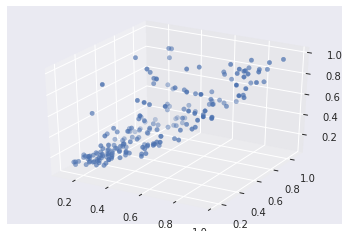

In [61]:
ax.scatter(matrix[0], matrix[1], matrix[2], marker='o')
plt.show()

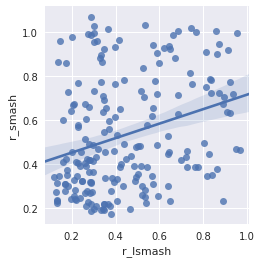

In [66]:
ax = sns.regplot(x='r_lsmash', y='r_smash', data=df)
ax.set_aspect('equal')
plt.show()

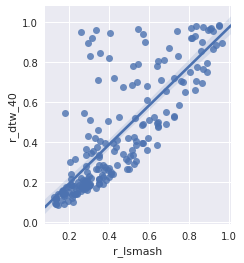

In [67]:
ax = sns.regplot(x='r_lsmash', y='r_dtw_40', data=df)
ax.set_aspect('equal')
plt.show()

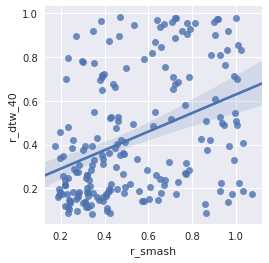

In [68]:
ax = sns.regplot(x='r_smash', y='r_dtw_40', data=df)
ax.set_aspect('equal')
plt.show()